<div style="background:linear-gradient(135deg,#0b1f33,#146c94);padding:22px;border-radius:14px;color:white">
<h1 style="margin:0">GeoAI Flood Digital Twin Workshop</h1>
<p style="font-size:16px;margin:8px 0 0 0">45-minute hands-on exercise using Hurricane Ian weather, real elevation, GeoAI flood prediction, and evacuation routing.</p>
</div>

**Goal:** Build a compact GeoAI flood digital twin for Orlando, Florida using Open-Meteo historical weather, USGS 3DEP DEM, terrain-aware flood simulation, Random Forest GeoAI prediction, risk mapping, shelter selection, OpenStreetMap routing, and replay sliders.

> **No API keys are required.** Internet is needed for Open-Meteo, USGS DEM, OpenStreetMap road download, and online map tiles. 

## 1 · Setup
Run this once. In Colab, the install may take a few minutes.

In [1]:
%pip install folium scikit-learn shapely geopandas branca ipywidgets osmnx networkx openmeteo-requests requests-cache retry-requests py3dep xarray rioxarray rasterio scipy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 61.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.5/240.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.3/731.3 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 108.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os, math, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium import FeatureGroup, LayerControl
import geopandas as gpd
from shapely.geometry import Polygon
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
warnings.filterwarnings("ignore")
np.random.seed(42)

USE_REAL_WEATHER = True
USE_REAL_DEM = True
USE_OSM_ROUTING = True
GRID = 34
CELL_DEG = 0.006
MILES_PER_METER = 0.000621371
# Enable ipywidgets in Colab
try:
    from google.colab import output as _colab_output
    _colab_output.enable_custom_widget_manager()
except ImportError:
    pass

print("✅ Libraries loaded")

✅ Libraries loaded


## 2 · Study Area
Default city is Orlando because the workshop recreates a Hurricane Ian 2022 flood-replay scenario.

In [3]:
CITIES = {
    "Orlando, Florida": {"lat": 28.5383, "lon": -81.3792},
    "Tampa, Florida":   {"lat": 27.9506, "lon": -82.4572},
    "Miami, Florida":   {"lat": 25.7617, "lon": -80.1918},
    "Houston, Texas":   {"lat": 29.7604, "lon": -95.3698},
}
SELECTED_CITY = "Orlando, Florida"
LAT = CITIES[SELECTED_CITY]["lat"]
LON = CITIES[SELECTED_CITY]["lon"]
print(f"Study area: {SELECTED_CITY}")
print(f"Center: {LAT:.4f}, {LON:.4f}")

Study area: Orlando, Florida
Center: 28.5383, -81.3792


## 3 · Real Weather: Hurricane Ian 2022 from Open-Meteo
Uses the Open-Meteo archive endpoint through the official SDK pattern. No API key is required.

In [4]:
def load_open_meteo_ian_weather(lat=LAT, lon=LON):
    import openmeteo_requests, requests_cache
    from retry_requests import retry
    cache_session = requests_cache.CachedSession(".cache", expire_after=3600)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": "2022-09-27", "end_date": "2022-10-02",
        "hourly": ["temperature_2m", "relative_humidity_2m", "precipitation", "rain", "wind_speed_10m", "wind_gusts_10m", "surface_pressure"],
        "timezone": "America/New_York",
    }
    response = openmeteo.weather_api(url, params=params)[0]
    hourly = response.Hourly()
    data = {"time": pd.date_range(start=pd.to_datetime(hourly.Time(), unit="s", utc=True), end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True), freq=pd.Timedelta(seconds=hourly.Interval()), inclusive="left")}
    data["temperature_c"] = hourly.Variables(0).ValuesAsNumpy()
    data["humidity_pct"] = hourly.Variables(1).ValuesAsNumpy()
    data["precip_mm"] = hourly.Variables(2).ValuesAsNumpy()
    data["rain_mm"] = hourly.Variables(3).ValuesAsNumpy()
    data["wind_speed_kmh"] = hourly.Variables(4).ValuesAsNumpy()
    data["wind_gust_kmh"] = hourly.Variables(5).ValuesAsNumpy()
    data["pressure_hpa"] = hourly.Variables(6).ValuesAsNumpy()
    df = pd.DataFrame(data)
    df["time"] = df["time"].dt.tz_convert("America/New_York")
    df["rain_in"] = df["precip_mm"] / 25.4
    df["cumulative_rain_in"] = df["rain_in"].cumsum()
    df["wind_mph"] = df["wind_speed_kmh"] * 0.621371
    df["gust_mph"] = df["wind_gust_kmh"] * 0.621371
    df["rain_factor"] = df["cumulative_rain_in"] / (df["cumulative_rain_in"].max() + 1e-9)
    df["wind_factor"] = df["gust_mph"] / (df["gust_mph"].max() + 1e-9)
    df["drainage"] = (1.0 - df["rain_factor"]).clip(0.20, 1.00)
    return df

def fallback_ian_weather():
    times = pd.date_range("2022-09-27", "2022-10-02 23:00", freq="h", tz="America/New_York")
    t = np.arange(len(times)); peak = 45
    rain_shape = np.exp(-((t - peak) / 14) ** 2)
    hourly_rain = 0.55 * rain_shape + 0.08 * np.exp(-((t - 30) / 10) ** 2)
    wind = 18 + 38 * np.exp(-((t - peak) / 18) ** 2)
    df = pd.DataFrame({"time": times, "temperature_c": 24 + 2*np.sin(t/24*2*np.pi), "humidity_pct": 85 + 10*rain_shape, "precip_mm": hourly_rain*25.4, "rain_mm": hourly_rain*25.4, "wind_speed_kmh": wind/0.621371, "wind_gust_kmh": (wind*1.35)/0.621371, "pressure_hpa": 1008 - 20*rain_shape})
    df["rain_in"] = df["precip_mm"] / 25.4
    df["cumulative_rain_in"] = df["rain_in"].cumsum()
    df["wind_mph"] = df["wind_speed_kmh"] * 0.621371
    df["gust_mph"] = df["wind_gust_kmh"] * 0.621371
    df["rain_factor"] = df["cumulative_rain_in"] / (df["cumulative_rain_in"].max() + 1e-9)
    df["wind_factor"] = df["gust_mph"] / (df["gust_mph"].max() + 1e-9)
    df["drainage"] = (1.0 - df["rain_factor"]).clip(0.20, 1.00)
    return df

try:
    weather_df = load_open_meteo_ian_weather() if USE_REAL_WEATHER else fallback_ian_weather()
    weather_source = "Open-Meteo Archive"
except Exception as e:
    print("⚠️ Open-Meteo failed. Using fallback Ian-shaped weather.")
    print("Reason:", e)
    weather_df = fallback_ian_weather()
    weather_source = "Fallback synthetic Ian-shaped weather"

print(f"Weather source: {weather_source}")
print(f"Total rainfall: {weather_df['cumulative_rain_in'].iloc[-1]:.2f} inches")
print(f"Peak hourly rain: {weather_df['rain_in'].max():.2f} in/hr")
print(f"Peak gust: {weather_df['gust_mph'].max():.1f} mph")
display(weather_df.head())

Weather source: Open-Meteo Archive
Total rainfall: 10.41 inches
Peak hourly rain: 1.45 in/hr
Peak gust: 59.3 mph


,time,temperature_c,humidity_pct,precip_mm,rain_mm,wind_speed_kmh,wind_gust_kmh,pressure_hpa,rain_in,cumulative_rain_in,wind_mph,gust_mph,rain_factor,wind_factor,drainage
0,2022-09-27 00:00:00-04:00,22.750000,93.521683,1.4,1.4,2.880000,13.679999,1009.215271,0.055118,0.055118,1.789548,8.500355,0.005297,0.143396,0.994703
1,2022-09-27 01:00:00-04:00,22.799999,94.097206,0.3,0.3,3.075841,5.400000,1009.116333,0.011811,0.066929,1.911239,3.355403,0.006432,0.056604,0.993568
2,2022-09-27 02:00:00-04:00,22.799999,95.252724,0.2,0.2,3.396233,6.480000,1008.717896,0.007874,0.074803,2.110321,4.026484,0.007189,0.067925,0.992811
3,2022-09-27 03:00:00-04:00,22.799999,96.127472,0.1,0.1,2.414953,6.120000,1008.020691,0.003937,0.078740,1.500582,3.802790,0.007567,0.064151,0.992433
4,2022-09-27 04:00:00-04:00,22.750000,97.008163,0.0,0.0,2.305125,4.680000,1007.322998,0.000000,0.078740,1.432338,2.908016,0.007567,0.049057,0.992433


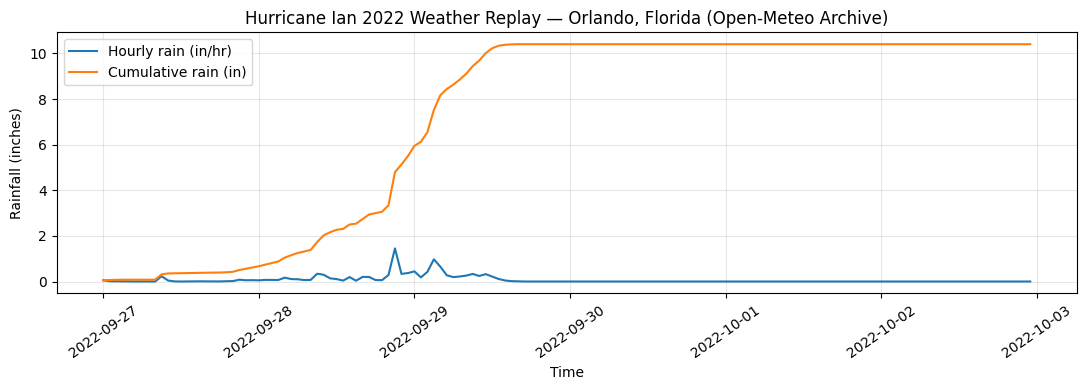

In [5]:
plt.figure(figsize=(11, 4))
plt.plot(weather_df["time"], weather_df["rain_in"], label="Hourly rain (in/hr)")
plt.plot(weather_df["time"], weather_df["cumulative_rain_in"], label="Cumulative rain (in)")
plt.title(f"Hurricane Ian 2022 Weather Replay — {SELECTED_CITY} ({weather_source})")
plt.xlabel("Time"); plt.ylabel("Rainfall (inches)"); plt.xticks(rotation=35); plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

## 4 · Real Elevation: USGS 3DEP DEM
Pulls a 30 m DEM around the study area using `py3dep`. If that fails, the notebook falls back to a synthetic terrain surface so the workshop can continue.

DEM source: USGS 3DEP DEM via py3dep
Elevation min/mean/max: 7.46 / 27.89 / 57.02 m


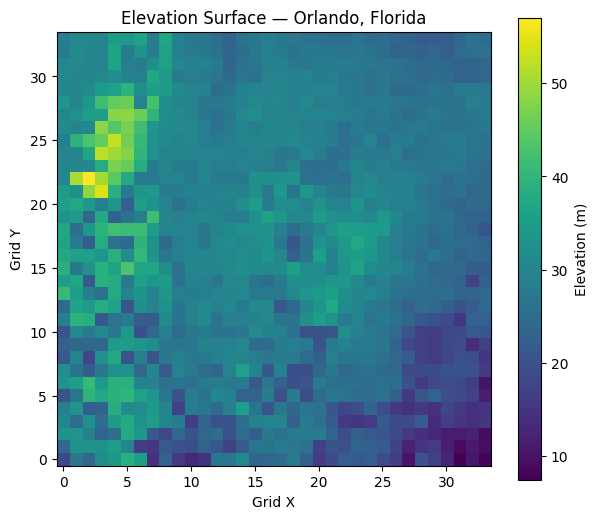

In [6]:
def load_usgs_dem(lat=LAT, lon=LON, grid=GRID, buffer_deg=0.12):
    import py3dep
    from scipy.ndimage import zoom as scipy_zoom
    bbox = (lon - buffer_deg, lat - buffer_deg, lon + buffer_deg, lat + buffer_deg)
    dem = py3dep.get_dem(bbox, resolution=30)
    dem_array = dem.values.astype(float)
    dem_array = np.where(np.isfinite(dem_array), dem_array, np.nan)
    dem_array = np.nan_to_num(dem_array, nan=np.nanmedian(dem_array))
    return scipy_zoom(dem_array, (grid/dem_array.shape[0], grid/dem_array.shape[1]), order=1)

def fallback_dem(grid=GRID):
    y, x = np.mgrid[0:grid, 0:grid]
    base = 28 + 4*(x/grid) + 2*np.sin(y/5)
    channel = 5*np.exp(-((x - grid*0.35)/4)**2)
    basin = 3*np.exp(-(((x-grid*0.65)**2 + (y-grid*0.45)**2)/(2*7**2)))
    return base - channel - basin

try:
    real_elevation = load_usgs_dem() if USE_REAL_DEM else fallback_dem()
    dem_source = "USGS 3DEP DEM via py3dep"
except Exception as e:
    print("⚠️ USGS DEM failed. Using fallback synthetic terrain.")
    print("Reason:", e)
    real_elevation = fallback_dem()
    dem_source = "Fallback synthetic terrain"

ELEVATION = real_elevation.astype(float)
elev_norm = (ELEVATION - ELEVATION.min()) / (ELEVATION.max() - ELEVATION.min() + 1e-9)
lowland_factor = 1.0 - elev_norm
slope_y, slope_x = np.gradient(ELEVATION)
slope = np.sqrt(slope_x**2 + slope_y**2)
slope_norm = slope / (slope.max() + 1e-9)
print(f"DEM source: {dem_source}")
print(f"Elevation min/mean/max: {ELEVATION.min():.2f} / {ELEVATION.mean():.2f} / {ELEVATION.max():.2f} m")
plt.figure(figsize=(7, 6)); plt.imshow(ELEVATION, origin="lower"); plt.colorbar(label="Elevation (m)"); plt.title(f"Elevation Surface — {SELECTED_CITY}"); plt.xlabel("Grid X"); plt.ylabel("Grid Y"); plt.show()

## 5 · Build Geospatial Grid and Features
Each grid cell becomes one spatial unit for GeoAI prediction and risk mapping.

In [7]:
def make_grid(lat0=LAT, lon0=LON, grid=GRID, cell_deg=CELL_DEG):
    records = []
    for i in range(grid):
        for j in range(grid):
            lat = lat0 + (i - grid/2) * cell_deg
            lon = lon0 + (j - grid/2) * cell_deg
            poly = Polygon([(lon-cell_deg/2, lat-cell_deg/2), (lon+cell_deg/2, lat-cell_deg/2), (lon+cell_deg/2, lat+cell_deg/2), (lon-cell_deg/2, lat+cell_deg/2)])
            records.append({"row": i, "col": j, "lat": lat, "lon": lon, "geometry": poly})
    return gpd.GeoDataFrame(records, crs="EPSG:4326")

grid_gdf = make_grid()
grid_gdf["elevation_m"] = ELEVATION.ravel()
grid_gdf["elev_norm"] = elev_norm.ravel()
grid_gdf["lowland_factor"] = lowland_factor.ravel()
grid_gdf["slope_norm"] = slope_norm.ravel()
r = grid_gdf["row"].values; c = grid_gdf["col"].values
center_dist = np.sqrt((r - GRID/2)**2 + (c - GRID/2)**2) / (GRID/2)
landuse = np.where(center_dist < 0.25, 2, 1)
landuse = np.where((c < GRID*0.30) & (grid_gdf["lowland_factor"].values > 0.60), 0, landuse)
landuse = np.where((r > GRID*0.70) & (c > GRID*0.60), 4, landuse)
landuse = np.where((abs(r-GRID*0.52) < 2) & (abs(c-GRID*0.55) < 2), 3, landuse)
grid_gdf["landuse"] = landuse
LU_LABELS = {0:"Water/Open", 1:"Residential", 2:"Commercial", 3:"Critical Facility", 4:"Green Space"}
grid_gdf["landuse_label"] = grid_gdf["landuse"].map(LU_LABELS)
population = (650 * (1 - center_dist) + 120*np.random.rand(len(grid_gdf))).clip(5, None)
population *= np.where(grid_gdf["landuse"].values == 2, 1.6, 1.0)
population *= np.where(grid_gdf["landuse"].values == 4, 0.35, 1.0)
grid_gdf["population"] = population.astype(int)
print(f"Grid cells: {len(grid_gdf)}")
display(grid_gdf[["row", "col", "lat", "lon", "elevation_m", "landuse_label", "population"]].head())

Grid cells: 1156


,row,col,lat,lon,elevation_m,landuse_label,population
0,0,0,28.4363,-81.4812,18.217932,Water/Open,5
1,0,1,28.4363,-81.4752,27.029318,Water/Open,5
2,0,2,28.4363,-81.4692,24.292193,Water/Open,5
3,0,3,28.4363,-81.4632,31.317842,Residential,5
4,0,4,28.4363,-81.4572,33.799582,Residential,5


## 6 · Terrain-Aware Flood Simulator
Simple simulation uses rainfall, wind, drainage, low elevation, and slope.

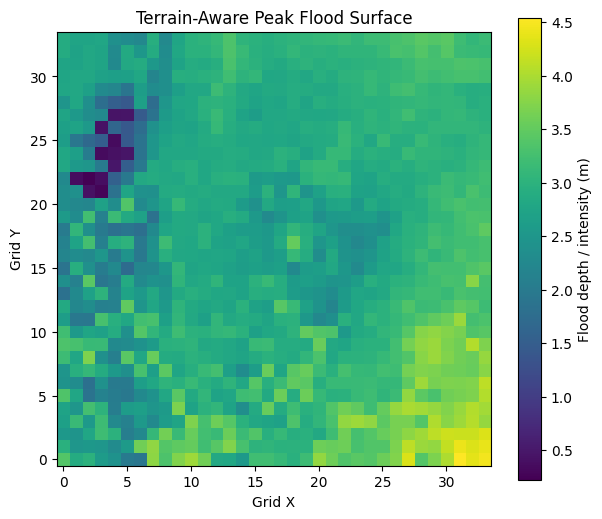

In [8]:
def simulate_dynamic_flood(rain_factor, wind_factor, drainage):
    base = 0.10 + 1.25 * lowland_factor + 0.45 * (1 - slope_norm) * lowland_factor
    flood = base * (0.25 + 2.10 * rain_factor) + 0.18 * wind_factor + 0.35 * (1 - drainage)
    flood[elev_norm > 0.80] *= 0.35
    return np.clip(flood, 0, None)

peak_idx = int(weather_df["rain_factor"].idxmax())
peak_row = weather_df.loc[peak_idx]
baseline_flood = simulate_dynamic_flood(float(peak_row["rain_factor"]), float(peak_row["wind_factor"]), float(peak_row["drainage"]))
grid_gdf["baseline_flood_m"] = baseline_flood.ravel()
CLS_LABELS = {0:"None/Minimal", 1:"Minor", 2:"Moderate", 3:"Major", 4:"Extreme"}
def classify_flood(depth):
    return np.digitize(depth, bins=[0.20, 0.50, 1.00, 1.80])
grid_gdf["flood_class"] = classify_flood(grid_gdf["baseline_flood_m"].values)
grid_gdf["flood_label"] = grid_gdf["flood_class"].map(CLS_LABELS)
plt.figure(figsize=(7, 6)); plt.imshow(baseline_flood, origin="lower"); plt.colorbar(label="Flood depth / intensity (m)"); plt.title("Terrain-Aware Peak Flood Surface"); plt.xlabel("Grid X"); plt.ylabel("Grid Y"); plt.show()

## 7 · GeoAI Model: Random Forest Flood Classification
Train a surrogate model over the Ian weather timeline and scaled variants.

GeoAI model accuracy: 0.997
              precision    recall  f1-score   support

None/Minimal       0.98      0.98      0.98       808
       Minor       1.00      0.99      1.00     21619
    Moderate       0.99      0.99      0.99     12377
       Major       0.99      0.99      0.99     11127
     Extreme       1.00      1.00      1.00     78917

    accuracy                           1.00    124848
   macro avg       0.99      0.99      0.99    124848
weighted avg       1.00      1.00      1.00    124848



,feature,importance
6,rain_factor,0.432395
8,drainage,0.304724
7,wind_factor,0.096057
0,elevation_m,0.051796
1,elev_norm,0.051156
2,lowland_factor,0.050226
3,slope_norm,0.010419
5,population,0.002705
4,landuse,0.000522


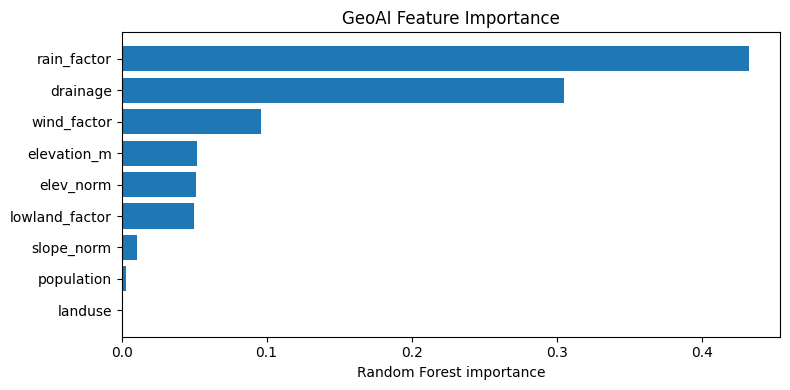

In [9]:
train_parts = []
for scale in [0.75, 1.00, 1.25]:
    for _, row in weather_df.iterrows():
        rain = min(1.0, float(row["rain_factor"]) * scale)
        wind = min(1.0, float(row["wind_factor"]) * scale)
        drainage = float(row["drainage"])
        flood = simulate_dynamic_flood(rain, wind, drainage).ravel()
        train_parts.append(pd.DataFrame({
            "elevation_m": grid_gdf["elevation_m"].values,
            "elev_norm": grid_gdf["elev_norm"].values,
            "lowland_factor": grid_gdf["lowland_factor"].values,
            "slope_norm": grid_gdf["slope_norm"].values,
            "landuse": grid_gdf["landuse"].values,
            "population": grid_gdf["population"].values,
            "rain_factor": rain,
            "wind_factor": wind,
            "drainage": drainage,
            "flood_class": classify_flood(flood),
        }))
train_df = pd.concat(train_parts, ignore_index=True)
features = ["elevation_m", "elev_norm", "lowland_factor", "slope_norm", "landuse", "population", "rain_factor", "wind_factor", "drainage"]
X = train_df[features]; y = train_df["flood_class"]
stratify_arg = y if y.value_counts().min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=stratify_arg
)
rf = RandomForestClassifier(n_estimators=180, random_state=42, min_samples_leaf=3, n_jobs=-1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print(f"GeoAI model accuracy: {accuracy_score(y_test, pred):.3f}")
print(classification_report(y_test, pred, target_names=[CLS_LABELS[i] for i in sorted(CLS_LABELS)]))
importance = pd.DataFrame({"feature": features, "importance": rf.feature_importances_}).sort_values("importance", ascending=False)
display(importance)
plt.figure(figsize=(8, 4)); plt.barh(importance["feature"], importance["importance"]); plt.gca().invert_yaxis(); plt.title("GeoAI Feature Importance"); plt.xlabel("Random Forest importance"); plt.tight_layout(); plt.show()

## 8 · Risk Scoring and Hotspot Detection
Risk combines flood severity, population exposure, terrain, and land-use sensitivity.

In [10]:
peak_features = grid_gdf.copy()
peak_features["rain_factor"] = float(peak_row["rain_factor"])
peak_features["wind_factor"] = float(peak_row["wind_factor"])
peak_features["drainage"] = float(peak_row["drainage"])
grid_gdf["geoai_flood_class"] = rf.predict(peak_features[features])
grid_gdf["geoai_flood_label"] = grid_gdf["geoai_flood_class"].map(CLS_LABELS)
pop_norm = grid_gdf["population"] / (grid_gdf["population"].max() + 1e-9)
landuse_weight = grid_gdf["landuse"].map({0:0.6, 1:0.8, 2:1.0, 3:1.2, 4:0.4}).values
flood_norm = grid_gdf["baseline_flood_m"] / (grid_gdf["baseline_flood_m"].max() + 1e-9)
grid_gdf["risk_score"] = 100 * (0.50*flood_norm + 0.25*pop_norm + 0.15*grid_gdf["lowland_factor"] + 0.10*landuse_weight/1.2)
def risk_tier(score):
    if score >= 75: return "CRITICAL"
    if score >= 55: return "HIGH"
    if score >= 35: return "MODERATE"
    return "LOW"
grid_gdf["risk_tier"] = grid_gdf["risk_score"].apply(risk_tier)
high_risk = grid_gdf[grid_gdf["risk_score"] >= grid_gdf["risk_score"].quantile(0.90)].copy()
if len(high_risk) >= 3:
    km = KMeans(n_clusters=min(3, len(high_risk)), random_state=42, n_init=10)
    high_risk["hotspot_cluster"] = km.fit_predict(high_risk[["lat", "lon"]])
else:
    high_risk["hotspot_cluster"] = 0
risk_centroid_lat = float(high_risk["lat"].mean()); risk_centroid_lon = float(high_risk["lon"].mean())
summary = grid_gdf.groupby("risk_tier").size().reindex(["LOW", "MODERATE", "HIGH", "CRITICAL"], fill_value=0)
display(summary.to_frame("cell_count"))
print(f"Risk centroid: {risk_centroid_lat:.4f}, {risk_centroid_lon:.4f}")

,cell_count
risk_tier,
LOW,40
MODERATE,702
HIGH,414
CRITICAL,0


Risk centroid: 28.4983, -81.3456


## 9 · Shelters and OSM Road Routing
Uses real OpenStreetMap road routing when available. The downloaded graph is cached as GraphML for reuse.

In [ ]:
import networkx as nx
shelters = pd.DataFrame({"name":["North Shelter","East Shelter","South Shelter","West Shelter"], "lat":[LAT+0.075, LAT+0.020, LAT-0.075, LAT-0.015], "lon":[LON-0.035, LON+0.090, LON+0.020, LON-0.095], "capacity":[450,600,500,350]})
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8; p1, p2 = math.radians(lat1), math.radians(lat2); dphi = math.radians(lat2-lat1); dlambda = math.radians(lon2-lon1)
    a = math.sin(dphi/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dlambda/2)**2
    return 2*R*math.asin(math.sqrt(a))
safe_city = SELECTED_CITY.lower().replace(",", "").replace(" ", "_")
osm_graph_path = Path(f"{safe_city}_osm_drive.graphml"); G = None; routing_source = "straight-line fallback"
if USE_OSM_ROUTING:
    try:
        import osmnx as ox
        ox.settings.use_cache = True; ox.settings.log_console = False
        if osm_graph_path.exists():
            G = ox.load_graphml(osm_graph_path); routing_source = "Cached OpenStreetMap graph"
        else:
            print("Downloading OSM road network once. No API key required.")
            G = ox.graph_from_point((LAT, LON), dist=18000, network_type="drive", simplify=True)
            G = ox.add_edge_speeds(G); G = ox.add_edge_travel_times(G); ox.save_graphml(G, osm_graph_path)
            routing_source = "OpenStreetMap road graph"
    except Exception as e:
        print("⚠️ OSM routing failed. Using straight-line fallback."); print("Reason:", e); G = None
route_records = []
if G is not None:
    import osmnx as ox
    origin_node = ox.distance.nearest_nodes(G, risk_centroid_lon, risk_centroid_lat)
    for _, s in shelters.iterrows():
        dest_node = ox.distance.nearest_nodes(G, s["lon"], s["lat"])
        try:
            route = nx.shortest_path(G, origin_node, dest_node, weight="travel_time")
            route_gdf = ox.routing.route_to_gdf(G, route) if hasattr(ox, "routing") else ox.utils_graph.route_to_gdf(G, route)
            length_m = route_gdf["length"].sum(); time_sec = route_gdf["travel_time"].sum() if "travel_time" in route_gdf else np.nan
            route_records.append({**s.to_dict(), "route": route, "route_miles": length_m*MILES_PER_METER, "travel_time_min": time_sec/60 if np.isfinite(time_sec) else np.nan})
        except Exception:
            miles = haversine_miles(risk_centroid_lat, risk_centroid_lon, s["lat"], s["lon"]); route_records.append({**s.to_dict(), "route": None, "route_miles": miles, "travel_time_min": miles/30*60})
else:
    for _, s in shelters.iterrows():
        miles = haversine_miles(risk_centroid_lat, risk_centroid_lon, s["lat"], s["lon"]); route_records.append({**s.to_dict(), "route": None, "route_miles": miles, "travel_time_min": miles/30*60})
shelters = pd.DataFrame(route_records)
shelters["distance_norm"] = shelters["route_miles"] / (shelters["route_miles"].max() + 1e-9)
shelters["time_norm"] = shelters["travel_time_min"] / (shelters["travel_time_min"].max() + 1e-9)
shelters["capacity_norm"] = shelters["capacity"] / (shelters["capacity"].max() + 1e-9)
# Higher score = better shelter (closer, faster, larger capacity)
shelters["geoai_shelter_score"] = (
    0.45 * (1 - shelters["distance_norm"]) +
    0.35 * (1 - shelters["time_norm"]) +
    0.20 * shelters["capacity_norm"]
)
best_shelter = shelters.sort_values("geoai_shelter_score", ascending=False).iloc[0]
print(f"Routing source: {routing_source}")
print(f"Selected shelter: {best_shelter['name']} | {best_shelter['route_miles']:.2f} miles | {best_shelter['travel_time_min']:.1f} min")
display(shelters[["name", "capacity", "route_miles", "travel_time_min", "geoai_shelter_score"]].style
    .format({"route_miles": "{:.2f} miles", "travel_time_min": "{:.1f} min", "geoai_shelter_score": "{:.3f}"})
    .bar(subset=["geoai_shelter_score"], color="#b3d9f7", vmin=0, vmax=1)
    .set_caption("Shelter selection using route distance, travel time, and capacity (higher score = better)"))

## 10 · Interactive Satellite Map
Overlays flood severity, risk cells, shelters, hotspot centroid, and the selected evacuation route.

In [13]:
CLS_COLORS = {0:"#d9f0f7", 1:"#ffffb2", 2:"#fd8d3c", 3:"#d7191c", 4:"#6d0000"}
RISK_COLORS = {"LOW":"#2ca25f", "MODERATE":"#fee08b", "HIGH":"#f46d43", "CRITICAL":"#7f0000"}
def add_osm_route_to_map(m, G, route, color="#00ff88"):
    if G is None or route is None: return False
    try:
        import osmnx as ox
        route_gdf = ox.routing.route_to_gdf(G, route) if hasattr(ox, "routing") else ox.utils_graph.route_to_gdf(G, route)
        coords = []
        for geom in route_gdf.geometry:
            if geom.geom_type == "LineString": coords.extend([(lat, lon) for lon, lat in geom.coords])
            elif geom.geom_type == "MultiLineString":
                for line in geom.geoms: coords.extend([(lat, lon) for lon, lat in line.coords])
        if coords:
            folium.PolyLine(coords, color=color, weight=5, opacity=0.9, tooltip=f"OSM route to {best_shelter['name']}").add_to(m); return True
    except Exception as e:
        print("Route drawing fallback:", e)
    return False
m = folium.Map(location=[LAT, LON], zoom_start=12, tiles=None)
folium.TileLayer("OpenStreetMap", name="OpenStreetMap").add_to(m)
folium.TileLayer(tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}", attr="Esri World Imagery", name="Satellite Imagery").add_to(m)
folium.TileLayer("CartoDB positron", name="Light Map").add_to(m)
flood_layer = FeatureGroup(name="GeoAI Flood Classes", show=True); risk_layer = FeatureGroup(name="High-Risk Cells", show=True); shelter_layer = FeatureGroup(name="Shelters + Evacuation Route", show=True)
for _, row in grid_gdf.iterrows():
    cls = int(row["geoai_flood_class"])
    if cls == 0: continue
    coords = [(lat, lon) for lon, lat in list(row.geometry.exterior.coords)]
    popup = f"""<b>Cell ({int(row['row'])}, {int(row['col'])})</b><br>GeoAI flood class: <b>{row['geoai_flood_label']}</b><br>Flood depth: {row['baseline_flood_m']:.2f} m<br>Elevation: {row['elevation_m']:.2f} m<br>Land use: {row['landuse_label']}<br>Population: {int(row['population'])}<br>Risk: <b>{row['risk_tier']}</b> ({row['risk_score']:.1f}/100)"""
    folium.Polygon(coords, color=CLS_COLORS[cls], fill=True, fill_color=CLS_COLORS[cls], fill_opacity=0.52, weight=0.5, popup=folium.Popup(popup, max_width=310), tooltip=f"{row['geoai_flood_label']} | Risk {row['risk_score']:.1f}").add_to(flood_layer)
for _, row in grid_gdf[grid_gdf["risk_tier"].isin(["HIGH", "CRITICAL"])].iterrows():
    folium.CircleMarker(location=[row.lat, row.lon], radius=3 if row.risk_tier == "HIGH" else 5, color="black", weight=0.5, fill=True, fill_color=RISK_COLORS[row.risk_tier], fill_opacity=0.85, tooltip=f"{row.risk_tier}: {row.risk_score:.1f}").add_to(risk_layer)
for _, s in shelters.iterrows():
    is_best = s["name"] == best_shelter["name"]
    popup = f"""<b>{s['name']}</b><br>Capacity: {int(s.capacity)} people<br>Route distance: {s.route_miles:.2f} miles<br>Travel time: {s.travel_time_min:.1f} min<br>GeoAI shelter score: {s.geoai_shelter_score:.3f}"""
    folium.Marker(location=[s.lat, s.lon], popup=popup, tooltip=s["name"], icon=folium.Icon(color="green" if is_best else "blue", icon="home", prefix="fa")).add_to(shelter_layer)
folium.CircleMarker(location=[risk_centroid_lat, risk_centroid_lon], radius=9, color="white", weight=2, fill=True, fill_color="purple", fill_opacity=0.9, popup="Highest-risk centroid", tooltip="Risk centroid").add_to(shelter_layer)
route_drawn = add_osm_route_to_map(m, G, best_shelter["route"] if "route" in best_shelter.index else None)
if not route_drawn:
    folium.PolyLine([[risk_centroid_lat, risk_centroid_lon], [best_shelter.lat, best_shelter.lon]], color="#00ff88", weight=5, opacity=0.9, tooltip="Fallback route line").add_to(shelter_layer)
flood_layer.add_to(m); risk_layer.add_to(m); shelter_layer.add_to(m)
legend = f"""<div style="position: fixed; bottom: 28px; left: 28px; z-index: 1000; background: white; padding: 12px 14px; border-radius: 8px; border: 1px solid #999; font-size: 12px; box-shadow: 2px 2px 6px rgba(0,0,0,0.25);"><b>GeoAI Flood Digital Twin</b><br><span style="color:#ffffb2">■</span> Minor<br><span style="color:#fd8d3c">■</span> Moderate<br><span style="color:#d7191c">■</span> Major<br><span style="color:#6d0000">■</span> Extreme<br><hr style="margin:6px 0;"><span style="color:#7f0000">●</span> High/Critical Risk<br><span style="color:#00ff88">━</span> Evacuation route<br><small>{routing_source}</small></div>"""
m.get_root().html.add_child(folium.Element(legend)); LayerControl(collapsed=False).add_to(m); display(m)

## 11 · Interactive Hurricane Ian Replay
Move the slider to see how the flood surface changes through the storm timeline.

In [ ]:
# ── Helper: build a Folium map for any flood surface ─────────────────────────
def build_replay_map(flood_surface, row, dynamic_class, dynamic_risk):
    m2 = folium.Map(location=[LAT, LON], zoom_start=12, tiles=None)
    folium.TileLayer(
        "OpenStreetMap", name="OpenStreetMap").add_to(m2)
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri World Imagery", name="Satellite Imagery").add_to(m2)

    fl = FeatureGroup(name="Dynamic Flood", show=True)
    rk = FeatureGroup(name="Dynamic Risk",  show=True)

    for idx2, cell in grid_gdf.iterrows():
        cls = int(dynamic_class[idx2])
        if cls == 0:
            continue
        coords = [(la, lo) for lo, la in list(cell.geometry.exterior.coords)]
        popup = (
            f"<b>Cell ({int(cell.row)}, {int(cell.col)})</b><br>"
            f"Flood class : <b>{CLS_LABELS[cls]}</b><br>"
            f"Depth index : {flood_surface.ravel()[idx2]:.2f} m<br>"
            f"Elevation   : {cell.elevation_m:.1f} m<br>"
            f"Land use    : {cell.landuse_label}<br>"
            f"Population  : ~{int(cell.population)}<br>"
            f"Risk score  : <b>{dynamic_risk[idx2]:.1f}/100</b>"
        )
        folium.Polygon(
            coords, color=CLS_COLORS[cls], fill=True,
            fill_color=CLS_COLORS[cls], fill_opacity=0.55, weight=0.4,
            popup=folium.Popup(popup, max_width=290),
            tooltip=f"{CLS_LABELS[cls]} | depth {flood_surface.ravel()[idx2]:.2f} m"
        ).add_to(fl)

    # Dynamic risk markers
    high_mask = dynamic_risk >= 55
    for idx2, cell in grid_gdf[high_mask].iterrows():
        tier = "CRITICAL" if dynamic_risk[idx2] >= 75 else "HIGH"
        folium.CircleMarker(
            location=[cell.lat, cell.lon],
            radius=5 if tier == "CRITICAL" else 3,
            color="black", weight=0.5, fill=True,
            fill_color=RISK_COLORS.get(tier, "red"), fill_opacity=0.88,
            tooltip=f"{tier} | score {dynamic_risk[idx2]:.0f}"
        ).add_to(rk)

    # Shelters + route (static)
    for _, s in shelters.iterrows():
        is_best = s["name"] == best_shelter["name"]
        folium.Marker(
            location=[s.lat, s.lon],
            tooltip=s["name"],
            icon=folium.Icon(color="green" if is_best else "blue",
                             icon="home", prefix="fa")
        ).add_to(rk)

    route_drawn = add_osm_route_to_map(m2, G, best_shelter.get("route"))
    if not route_drawn:
        folium.PolyLine(
            [[risk_centroid_lat, risk_centroid_lon],
             [best_shelter.lat, best_shelter.lon]],
            color="#00ff88", weight=5, opacity=0.9
        ).add_to(rk)

    # Dynamic summary banner
    n_major = int((dynamic_class >= 3).sum())
    n_crit  = int((dynamic_risk >= 75).sum())
    banner = (
        f'<div style="position:fixed;top:14px;left:50px;z-index:1000;'
        f'background:rgba(11,31,51,0.88);color:white;padding:10px 14px;'
        f'border-radius:8px;font-size:12px;font-family:sans-serif;line-height:1.5">'
        f'<b>🌪️ Hurricane Ian — {row["time"].strftime("%b %d %H:00") if hasattr(row["time"],"strftime") else str(row["time"])[:13]}</b><br>'
        f'Cum. rain: {row["cumulative_rain_in"]:.2f} in  |  Gust: {row["gust_mph"]:.1f} mph<br>'
        f'Flood depth max: {flood_surface.max():.2f} m  |  Major+ cells: {n_major}<br>'
        f'Critical-risk cells: {n_crit}'
        f'</div>'
    )
    m2.get_root().html.add_child(folium.Element(banner))

    legend = (
        '<div style="position:fixed;bottom:28px;left:28px;z-index:1000;background:white;'        'padding:12px 14px;border-radius:8px;border:1px solid #bbb;font-size:12px;'        'box-shadow:2px 2px 6px rgba(0,0,0,0.2)">'        '<b>GeoAI Flood Digital Twin</b><br>'        '<span style="color:#ffffb2;font-size:16px">■</span> Minor<br>'        '<span style="color:#fd8d3c;font-size:16px">■</span> Moderate<br>'        '<span style="color:#d7191c;font-size:16px">■</span> Major<br>'        '<span style="color:#6d0000;font-size:16px">■</span> Extreme<br>'        '<hr style="margin:5px 0">'        '<span style="color:#7f0000">●</span> High / Critical risk'        '</div>'
    )
    m2.get_root().html.add_child(folium.Element(legend))
    fl.add_to(m2); rk.add_to(m2)
    LayerControl(collapsed=False).add_to(m2)
    return m2

# ── Slider widget ─────────────────────────────────────────────────────────────
time_slider = widgets.IntSlider(
    min=0, max=len(weather_df)-1,
    step=1, value=int(len(weather_df)*0.45),
    description="🌪️ Ian hour",
    continuous_update=False,
    style={"description_width": "90px"},
    layout=widgets.Layout(width="70%"))

out_map    = widgets.Output()
out_charts = widgets.Output()

def replay_ian(change=None):
    t   = time_slider.value
    row = weather_df.iloc[t]

    rain     = float(row["rain_factor"])
    wind     = float(row["wind_factor"])
    drainage = float(row["drainage"])

    # Recompute flood surface
    flood_surface  = simulate_dynamic_flood(rain, wind, drainage)
    dynamic_class  = classify_flood(flood_surface.ravel())

    # Recompute risk per cell at this timestep
    flood_norm_t  = flood_surface.ravel() / (flood_surface.max() + 1e-9)
    pop_norm_t    = grid_gdf["population"].values / (grid_gdf["population"].max() + 1e-9)
    lw_t          = grid_gdf["landuse"].map({0:0.6,1:0.8,2:1.0,3:1.2,4:0.4}).values
    lf_t          = grid_gdf["lowland_factor"].values
    dynamic_risk  = np.clip(100*(0.50*flood_norm_t + 0.25*pop_norm_t + 0.15*lf_t + 0.10*lw_t/1.2), 0, 100)

    # Update Folium map
    with out_map:
        clear_output(wait=True)
        m2 = build_replay_map(flood_surface, row, dynamic_class, dynamic_risk)
        display(m2)

        # Stats card
        n_major = int((dynamic_class >= 3).sum())
        n_crit  = int((dynamic_risk  >= 75).sum())
        pop_at_risk = int(grid_gdf["population"].values[dynamic_risk >= 55].sum())
        stats = {
            "☔ Cum. rain": f"{row['cumulative_rain_in']:.2f} in",
            "💧 Rate":      f"{row['rain_in']:.2f} in/hr",
            "💨 Gust":      f"{row['gust_mph']:.1f} mph",
            "🌊 Major+ cells": str(n_major),
            "🔴 Critical risk": str(n_crit),
            "👥 Pop at risk":   f"{pop_at_risk:,}",
        }
        row_html = "".join(
            f'<td style="padding:7px 18px;border-right:1px solid #e0e0e0;text-align:center">'            f'<div style="font-size:11px;color:#666;font-weight:bold">{k}</div>'            f'<div style="font-size:17px;font-weight:bold;color:#1e5f9e">{v}</div></td>'
            for k, v in stats.items()
        )
        display(HTML(
            f'<table style="border-collapse:collapse;background:#f8f9fa;'            f'border-radius:8px;overflow:hidden;margin:8px 0">'            f'<tr>{row_html}</tr></table>'
        ))

    # Update weather timeline chart
    with out_charts:
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))
        fig.suptitle("Hurricane Ian — Real Weather Timeline", fontsize=11, fontweight="bold")

        past = weather_df.iloc[:t+1]
        ax1.fill_between(weather_df["time"], weather_df["cumulative_rain_in"],
                         alpha=0.15, color="#1e5f9e")
        ax1.fill_between(past["time"], past["cumulative_rain_in"],
                         alpha=0.5, color="#1e5f9e")
        ax1.plot(past["time"], past["cumulative_rain_in"],
                 color="#1e5f9e", lw=2)
        ax1.axvline(row["time"], color="crimson", lw=1.5, ls="--")
        ax1.set_ylabel("Cumulative rain (in)")
        ax1.set_title("Rainfall accumulation", fontweight="bold")
        ax1.tick_params(axis="x", rotation=30)

        ax2.fill_between(weather_df["time"], weather_df["gust_mph"],
                         alpha=0.12, color="#e05c47")
        ax2.plot(past["time"], past["gust_mph"],
                 color="#e05c47", lw=2)
        ax2.axvline(row["time"], color="crimson", lw=1.5, ls="--", label="Current")
        ax2.set_ylabel("Wind gust (mph)")
        ax2.set_title("Wind gusts", fontweight="bold")
        ax2.tick_params(axis="x", rotation=30)
        ax2.legend(fontsize=9)

        plt.tight_layout()
        plt.show()

time_slider.observe(replay_ian, names="value")

display(widgets.VBox([
    widgets.HTML(
        '<b style="font-size:14px">🌪️ Hurricane Ian GeoAI Replay</b><br>'        '<span style="font-size:12px;color:#555">Drag slider — satellite map, risk scores, '        'and weather charts all update in real time</span>'
    ),
    time_slider,
    out_map,
    out_charts,
]))
replay_ian()


## 12 · What Makes This GeoAI?

This workshop uses GeoAI because spatial data are not just visualized; they are used in prediction and decision support:

1. **Geospatial inputs:** DEM elevation, lowland factor, slope, land use, population, rainfall, wind, drainage.
2. **AI model:** Random Forest predicts flood class from geospatial and weather features.
3. **Spatial decision intelligence:** risk hotspots drive shelter routing.
4. **Digital twin behavior:** weather timeline updates flood state and risk interpretation.

## 13 · Optional Export
Run this only if you want to save the final state.

In [ ]:
export_cols = ["row", "col", "lat", "lon", "elevation_m", "landuse_label", "population", "baseline_flood_m", "geoai_flood_class", "geoai_flood_label", "risk_score", "risk_tier"]
export_df = pd.DataFrame(grid_gdf[export_cols])
export_path = "geoai_flood_dt_state.csv"
export_df.to_csv(export_path, index=False)
print(f"✅ Exported: {export_path}")

## 14 · Discussion Prompts

- Which features were most important in the GeoAI model?
- How did real elevation change the flood pattern?
- Why is road-route distance better than straight-line distance for evacuation?
- What additional real-world layers would improve the model? Examples: building footprints, storm drains, road closures, stream gauges, flood insurance maps, and real shelter capacity feeds.